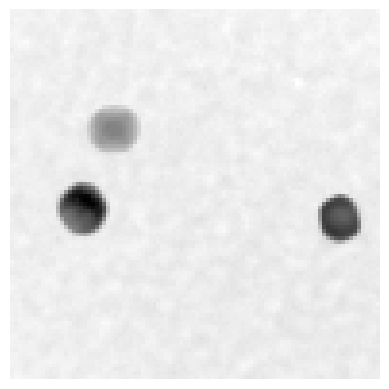

In [41]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load("../96x96_tem_downsampled.npy")

first_image = data[0].squeeze()

plt.imshow(first_image, cmap="gray")
plt.axis("off")
plt.show()

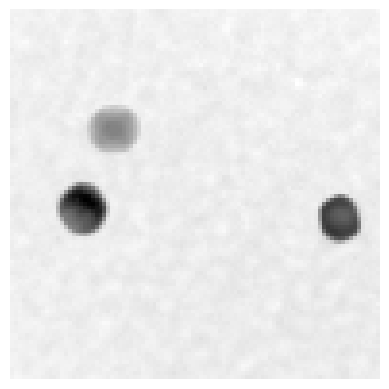

In [42]:
unique_val_image = first_image.astype(np.float64)

unique_val_image = unique_val_image + 1e-6 * np.random.randn(*unique_val_image.shape)

plt.imshow(unique_val_image, cmap="gray")
plt.axis("off")
plt.show()

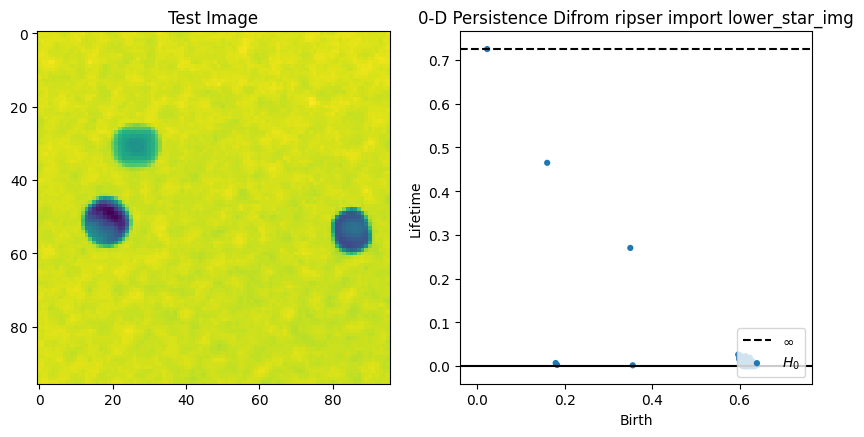

In [43]:
from ripser import lower_star_img
from persim import plot_diagrams

dgm = lower_star_img(unique_val_image)

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(unique_val_image)
plt.title("Test Image")
plt.subplot(122)
plot_diagrams(dgm, lifetime=True)
plt.title("0-D Persistence Difrom ripser import lower_star_img")
from persim import plot_diagrams

In [56]:
import numpy as np
from scipy.ndimage import label
from ripser import lower_star_img

def persistent_region_segmentation(
    image,
    threshold,
    dgm,
):

    labels_out = np.zeros(image.shape, dtype=np.int32)
    next_label = 1

    life = dgm[:,1] - dgm[:,0]

    idxs = np.where((life > threshold))[0] #&(dgm[:,1] != np.inf))

    h, w =image.shape

    for i in idxs:

        birth = dgm[i, 0]
        death = dgm[i, 1]
        if death == np.inf:
            death = 0.7
        
        #birth_locations = np.argwhere(np.abs(image - birth) < 1e-8)

        #if len(birth_locations) != 1:
        #    print("too many options")
        #    continue

        r, c = np.unravel_index(np.argmin(np.abs(image - birth)), image.shape)

        mask = image <= ((birth + death) / 2)

        cc_labels, _ = label(mask)

        component_id = cc_labels[r, c]

        if component_id == 0:
            continue

        region = cc_labels == component_id


        region &= (labels_out == 0)

        labels_out[region] = next_label

        next_label += 1

    return labels_out, dgm

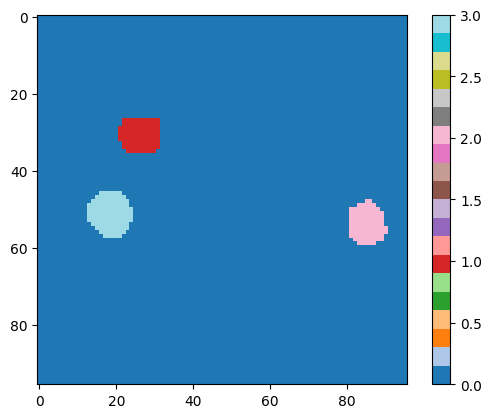

In [48]:
#using (birth + death)/2

seg, dgm= persistent_region_segmentation(unique_val_image, 0.2, dgm)
plt.imshow(seg, cmap="tab20")
plt.colorbar()
plt.show()

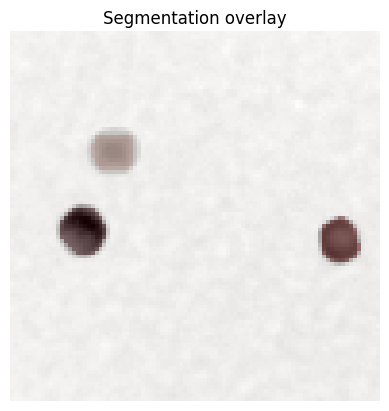

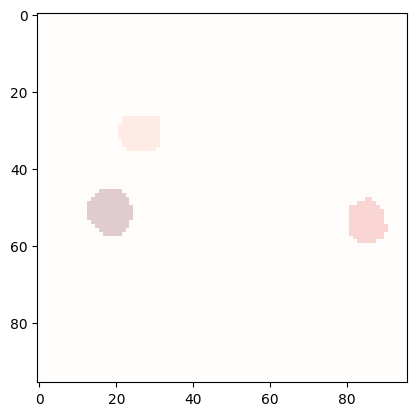

In [49]:
plt.imshow(unique_val_image, cmap='gray')  

plt.imshow(seg, cmap='Reds', alpha=0.2)

plt.title("Segmentation overlay")
plt.axis("off")
plt.show()
plt.imshow(seg, cmap='Reds', alpha=0.2)

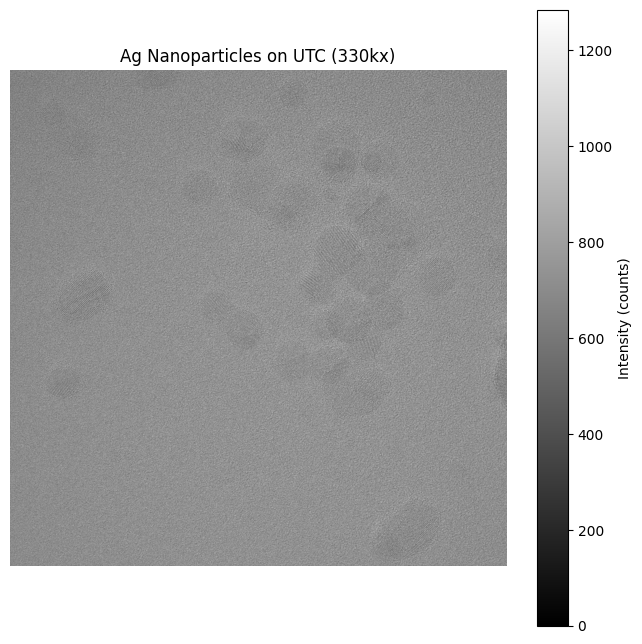

In [1]:
from ncempy.io import dm
from pathlib import Path
import matplotlib.pyplot as plt

file = Path("hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/20220202_Ag_UTC_330kx_2650e_0p1596s_02.dm3")

# Load the DM3 file
data_dict = dm.dmReader(str(file.resolve()))

image_data = data_dict['data']

plt.figure(figsize=(8, 8))
plt.imshow(image_data, cmap='gray')
plt.title("Ag Nanoparticles on UTC (330kx)")
plt.colorbar(label='Intensity (counts)')
plt.axis('off')  # Hides pixel coordinates for a cleaner look
plt.show()

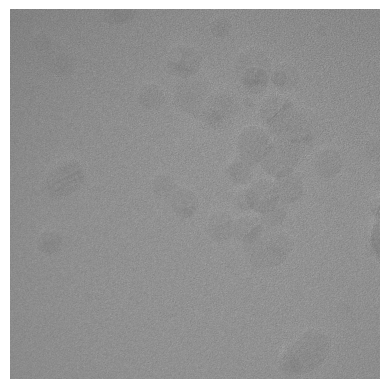

In [35]:
unique_val_image_2 = image_data.astype(np.float64)

unique_val_image_2 = unique_val_image_2 + 1e-6 * np.random.randn(*unique_val_image_2.shape)

plt.imshow(unique_val_image_2, cmap="gray")
plt.axis("off")
plt.show()

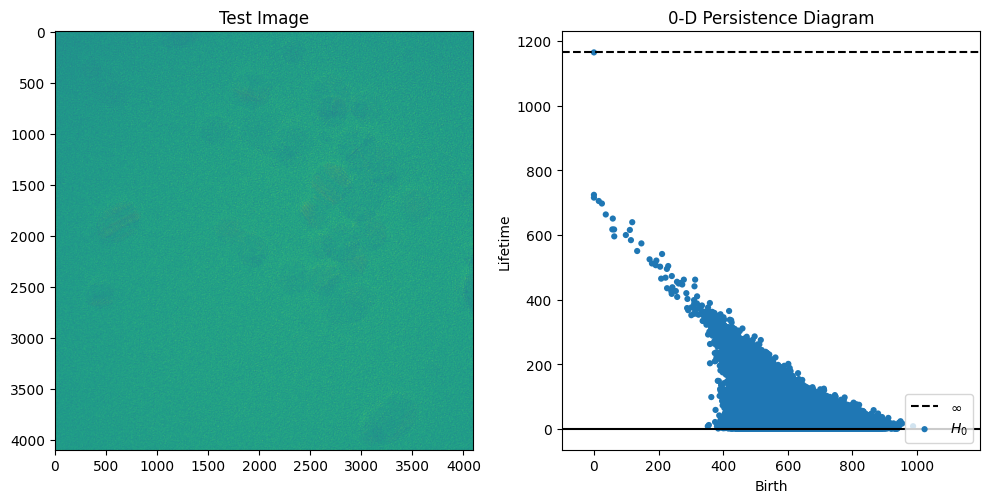

In [36]:
from ripser import lower_star_img
from persim import plot_diagrams

dgm_2 = lower_star_img(unique_val_image_2)

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(unique_val_image_2)
plt.title("Test Image")
plt.subplot(122)
plot_diagrams(dgm_2, lifetime=True)
plt.title("0-D Persistence Diagram")
plt.tight_layout()
plt.show()

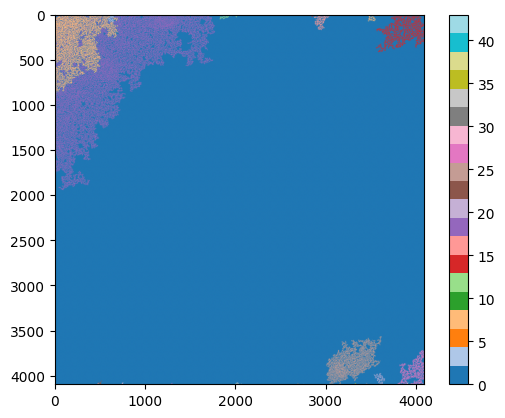

In [38]:
seg_2, dgm_2= persistent_region_segmentation(unique_val_image_2, 400, dgm_2)
plt.imshow(seg_2, cmap="tab20")
plt.colorbar()
plt.show()

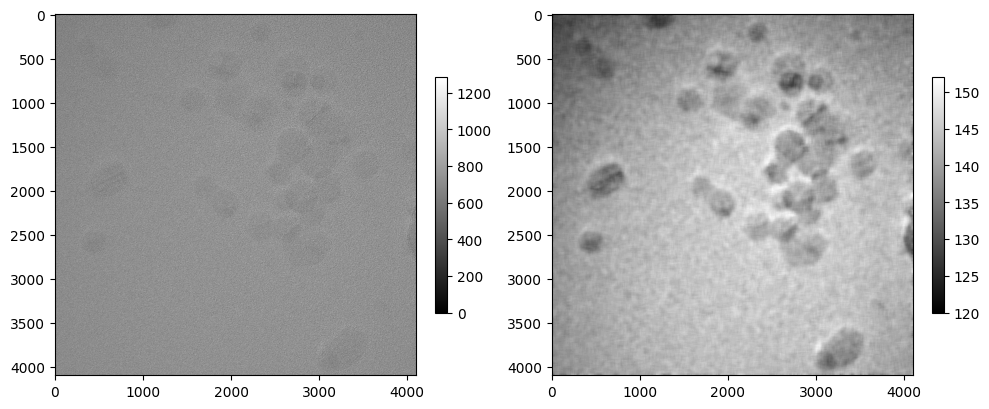

In [2]:
import numpy as np
import skimage.filters as filters
import cv2
from scipy import ndimage

smoothed_normalized = cv2.normalize(image_data, None, 0, 255, cv2.NORM_MINMAX)
smoothed_uint8 = smoothed_normalized.astype(np.uint8)
smoothed = cv2.medianBlur(smoothed_uint8, 61)

plt.figure(figsize=(10, 5))
plt.subplot(121)
im = plt.imshow(image_data, cmap="gray")
plt.colorbar(im, fraction=0.03)

plt.subplot(122)
im = plt.imshow(smoothed, cmap="gray")
plt.colorbar(im, fraction=0.03)

plt.tight_layout()
plt.show()

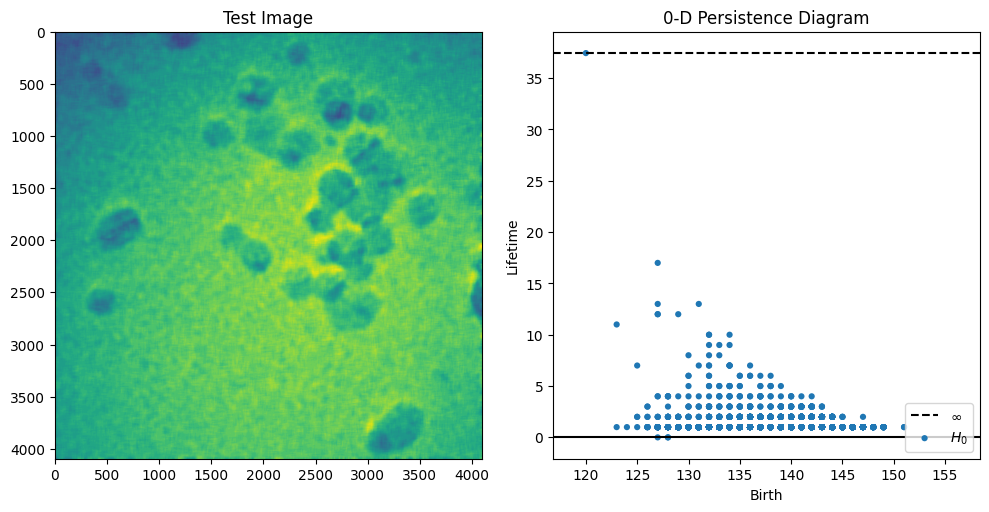

In [53]:
from ripser import lower_star_img
from persim import plot_diagrams

unique_val_image_2 = smoothed.astype(np.float64)

unique_val_image_2 = unique_val_image_2 + 1e-6 * np.random.randn(*unique_val_image_2.shape)

dgm_2_smoothed = lower_star_img(unique_val_image_2)

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(unique_val_image_2)
plt.title("Test Image")
plt.subplot(122)
plot_diagrams(dgm_2_smoothed, lifetime=True)
plt.title("0-D Persistence Diagram")
plt.tight_layout()
plt.show()

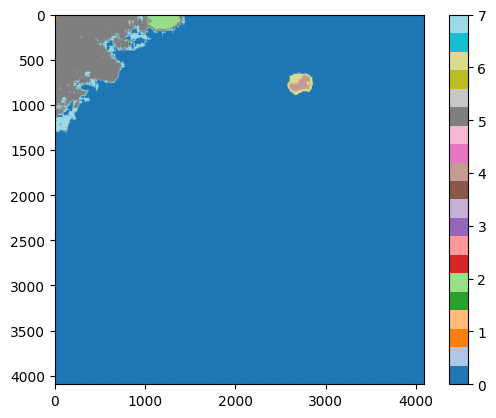

In [57]:
#using (birth + death) / 2

seg_2_smoothed, dgm_2_smoothed= persistent_region_segmentation(unique_val_image_2, 10, dgm_2_smoothed)
plt.imshow(seg_2_smoothed, cmap="tab20")
plt.colorbar()
plt.show()

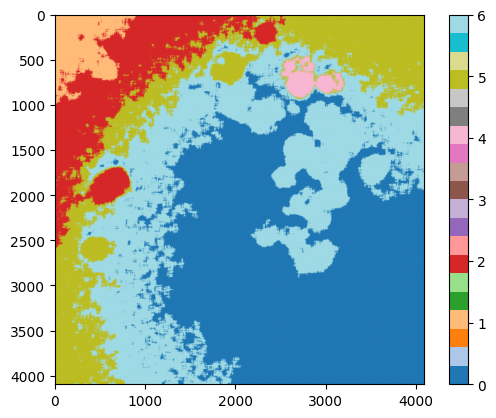

In [55]:
#using death

seg_2_smoothed, dgm_2_smoothed= persistent_region_segmentation(unique_val_image_2, 10, dgm_2_smoothed)
plt.imshow(seg_2_smoothed, cmap="tab20")
plt.colorbar()
plt.show()